In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# DATA ACQUISITION (DAQ)

In [7]:
#dataset path definition
dataset_path = "/home/andco/Dropbox/Università/Università di Pisa/Corsi di Studio/Artificial intelligence for cybersecurity/2025-26/Project/capture20110815-2.csv"

In [8]:
print("--- Dataset loading... ---")

#load dataset
df = pd.read_csv(dataset_path)

print("--- Dataset loaded ---")

#number of rows and columns
print(f"Dimension of dataset: {df.shape}")

#dataset info
df.info()

print("--- Dataset types ---")
print(df.dtypes)

print("--- Verify correct load ---")
df.head()

--- Dataset loading... ---
--- Dataset loaded ---
Dimension of dataset: (129832, 15)
<class 'pandas.DataFrame'>
RangeIndex: 129832 entries, 0 to 129831
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   StartTime  129832 non-null  str    
 1   Dur        129832 non-null  float64
 2   Proto      129832 non-null  str    
 3   SrcAddr    129832 non-null  str    
 4   Sport      129035 non-null  str    
 5   Dir        129832 non-null  str    
 6   DstAddr    129832 non-null  str    
 7   Dport      129455 non-null  str    
 8   State      129832 non-null  str    
 9   sTos       128974 non-null  float64
 10  dTos       122936 non-null  float64
 11  TotPkts    129832 non-null  int64  
 12  TotBytes   129832 non-null  int64  
 13  SrcBytes   129832 non-null  int64  
 14  Label      129832 non-null  str    
dtypes: float64(3), int64(3), str(9)
memory usage: 14.9 MB
--- Dataset types ---
StartTime        str
Dur          flo

,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,2011/08/15 16:43:28.078942,0.000000,tcp,114.33.245.44,6881,?>,147.32.84.118,1567,RA_,0.0,0.0,1,60,60,flow=Background
1,2011/08/15 16:43:32.283576,13.431962,tcp,212.93.105.52,49237,->,147.32.84.229,80,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
2,2011/08/15 16:43:32.456441,13.350228,tcp,212.93.105.52,14906,->,147.32.84.229,13363,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
3,2011/08/15 16:43:32.850648,13.010090,tcp,212.93.105.52,60349,->,147.32.84.229,443,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
4,2011/08/15 16:45:09.305002,20.990047,tcp,115.127.24.116,3198,->,147.32.84.229,443,SR_SA,0.0,0.0,5,308,122,flow=Background-TCP-Established


# DATA EXPLORATION (STATS & VISUALIZATION)

## Analysis of the Target variable ('Label')

In [ ]:
print("\n--- Statistical exploration start ---")

#Analysis of the Target variable ('Label')
print("Distribution of original classes in the 'Label' column:")
print(df['Label'].value_counts(dropna=False))


--- Statistical exploration start ---
Distribution of original classes in the 'Label' column:
Label
flow=To-Background-UDP-CVUT-DNS-Server                      50817
flow=Background-UDP-Established                             37203
flow=Background-TCP-Established                             15156
flow=Background-Established-cmpgw-CVUT                       9331
flow=Background                                              3426
                                                            ...  
flow=From-Botnet-V46-TCP-HTTP-Google-Net-Established-6          1
flow=From-Botnet-V46-TCP-CC7-Custom-Encryption                  1
flow=From-Botnet-V46-TCP-Established-HTTP-Ad-4                  1
flow=From-Botnet-V46-TCP-Established-Custom-Encryption-8        1
flow=From-Botnet-V46-TCP-Established                            1
Name: count, Length: 77, dtype: int64


## Binary mapping

In [ ]:
# create target column: 1 if string contains 'Botnet', 0 otherwise (Normal and Background)
df['Target'] = df['Label'].apply(lambda x: 1 if 'Botnet' in str(x) else 0)
print("\nDistribution after binary mapping (Target):")
target_counts = df['Target'].value_counts()
print(target_counts)


Distribution after binary mapping (Target):
Target
0    128931
1       901
Name: count, dtype: int64



Class 0 (Normal/Background): 99.31%

Class 1(Botnet): 0.69%


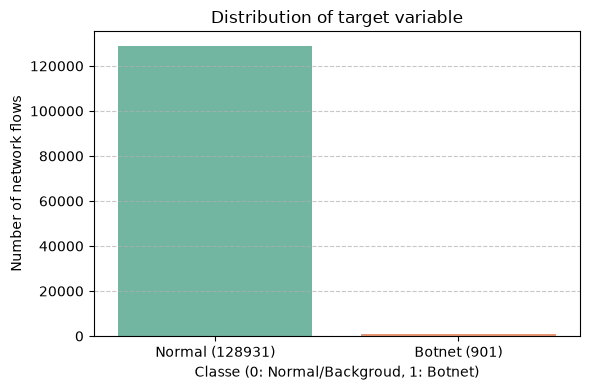

In [16]:
#percentage imbalance
p_normal = (target_counts[0] / len(df)) * 100
p_botnet = (target_counts[1] / len(df)) * 100
print(f"\nClass 0 (Normal/Background): {p_normal:.2f}%")
print(f"\nClass 1(Botnet): {p_botnet:.2f}%")

#graphic display of the imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='Target', hue='Target', data=df, palette='Set2', legend=False)
plt.title('Distribution of target variable')
plt.xlabel('Classe (0: Normal/Backgroud, 1: Botnet)')
plt.ylabel('Number of network flows')
plt.xticks([0,1], [f"Normal ({target_counts[0]})", f'Botnet ({target_counts[1]})'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Numerical feature exploration


Descriptive statistics of numerical features:
                 Dur           dTos        TotPkts      TotBytes      SrcBytes
count  129832.000000  122936.000000  129832.000000  1.298320e+05  1.298320e+05
mean       77.439645       0.000724      34.514927  2.883615e+04  5.081775e+03
std       282.290550       0.043716    2494.261137  2.962769e+06  5.179676e+05
min         0.000000       0.000000       1.000000  6.000000e+01  0.000000e+00
25%         0.000304       0.000000       2.000000  2.140000e+02  7.600000e+01
50%         0.000739       0.000000       2.000000  2.660000e+02  8.100000e+01
75%         0.643476       0.000000       6.000000  7.410000e+02  4.600000e+02
max      1805.828491       3.000000  694553.000000  8.537041e+08  1.365468e+08


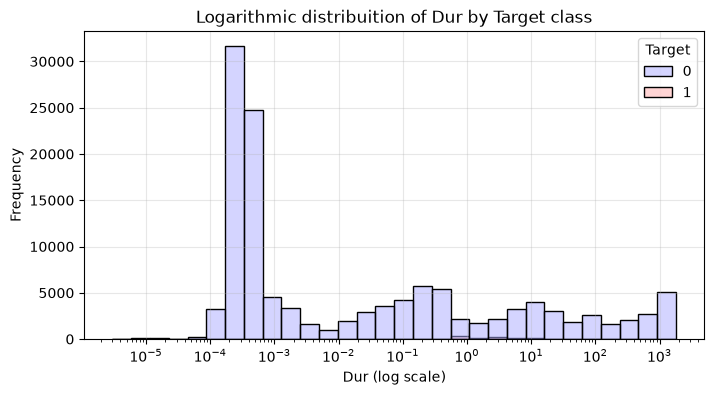

In [19]:
#numerical feature exploration
numerical_features = ['Dur', 'dTos', 'TotPkts', 'TotBytes', 'SrcBytes']

existing_numerical_features = [col for col in numerical_features if col in df.columns]

if existing_numerical_features:
    print("\nDescriptive statistics of numerical features:")
    print(df[existing_numerical_features].describe())

    #visualizing the distribution of a key feature
    plt.figure(figsize=(8,4))

    #logarithmic scale on the X-axis
    sns.histplot(data=df, x=existing_numerical_features[0], hue='Target', bins=30, kde=False, palette='bwr', log_scale=True)
    plt.title(f'Logarithmic distribuition of {existing_numerical_features[0]} by Target class')
    plt.xlabel(f'{existing_numerical_features[0]} (log scale)')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("\nNo numerical features found in the dataset for analysis.")

# Data Preprocessing

In [ ]:
print("\n --- Start Data Preprocessing ---")

## TIME VARIABLE MANAGEMENT (StartTime)

In [21]:
#convert StartTime to datetime
df['StartTime'] = pd.to_datetime(df['StartTime'])

#extracting hour of the day
df['HourOfDay'] = df['StartTime'].dt.hour
print("[Temporal Feature]: Extracted 'HourOfDay' from 'StartTime'.")

[Temporal Feature]: Extracted 'HourOfDay' from 'StartTime'.


## FEATURE SELECTION & TRANSFORMATION

In [22]:
#select clean numeric features and exclude rigid identifiers (IP)
#include 'dTos' while handling its missing values

#imputation of missing values ​​for dTos
df['dTos'] = df['dTos'].fillna(0)

#definition of Feature matrix (X) and Target vector (y)
selected_features = ['Dur', 'dTos', 'TotPkts', 'TotBytes', 'SrcBytes', 'HourOfDay']
X = df[selected_features]
y = df['Target']

print(f"[Feature Selection]: Select the features for training: {selected_features}")

[Feature Selection]: Select the features for training: ['Dur', 'dTos', 'TotPkts', 'TotBytes', 'SrcBytes', 'HourOfDay']


## SPLIT TRAIN / TEST (Hold-Out iniziale)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=43, stratify=y)

print(f"[Train/Test Split]: Train Dimensions: {X_train.shape[0]}, Test Dimensions: {X_test.shape[0]}")

[Train/Test Split]: Train Dimensions: 90882, Test Dimensions: 38950


# NORMALIZZAZIONE (Feature Scaling)

In [24]:
scaler = StandardScaler()

#apply fit_transform on the Train and only transform on the Test (to avoid data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("[Normalization]: Feature standardization completed (mean=0, variance=1).")

[Normalization]: Feature standardization completed (mean=0, variance=1).


## RE-BALANCING DELLE CLASSI (Tramite SMOTE)

In [ ]:
#generate synthetic instances of the least represented class

In [25]:
print(f"Pre-SMOTE Class Distribution (Train): {np.bincount(y_train)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Post-SMOTE Class Distribution (Train): {np.bincount(y_train_resampled)}")
print("--- Data Preprocessing Completed ---")

Pre-SMOTE Class Distribution (Train): [90251   631]
Post-SMOTE Class Distribution (Train): [90251 90251]
--- Data Preprocessing Completed ---


# Data Processing & Modeling

In [26]:
print("--- Start Data Processing & Modeling ---")

--- Start Data Processing & Modeling ---


## LOGISTIC REGRESSION

In [31]:
print("\n --- [Model 1] Logistic Regression Training ---")

# high max_iter to ensure gradient convergence
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_resampled, y_train_resampled)
print("-> Logistic regression trained.")


 --- [Model 1] Logistic Regression Training ---
-> Logistic regression trained.


## DECISION TREE

In [32]:
print("\n[Model 2] Decision Tree Training ---")
#set max_depth=5 to avoid overfitting (too deep trees store noise)
#use the 'gini' criterion
model_dt = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
model_dt.fit(X_train_resampled, y_train_resampled)
print("-> Decision tree trained.")


[Model 2] Decision Tree Training ---
-> Decision tree trained.


## RANDOM FOREST

In [33]:
print("\n --- [Model 3] Random Forest Training ---")
#create a "forest" of 100 different decision trees that vote by majority vote
model_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model_rf.fit(X_train_resampled, y_train_resampled)

print("-> Random forest trained.")

print("\n --- Completed: All models are ready for evaluation! ---")


 --- [Model 3] Random Forest Training ---
-> Random forest trained.

 --- Completed: All models are ready for evaluation! ---


# Model Evaluation

--- Start Model Evaluation ---

--- Evaluating Logistic Regression ---
                   precision    recall  f1-score   support

Normal/Background       1.00      0.59      0.74     38680
           Botnet       0.01      0.78      0.03       270

         accuracy                           0.59     38950
        macro avg       0.51      0.68      0.38     38950
     weighted avg       0.99      0.59      0.74     38950

Confusion Matrix di Logistic Regression:
 [[22856 15824]
 [   60   210]]

--- Evaluating Decision Tree ---
                   precision    recall  f1-score   support

Normal/Background       1.00      0.87      0.93     38680
           Botnet       0.05      0.93      0.09       270

         accuracy                           0.87     38950
        macro avg       0.52      0.90      0.51     38950
     weighted avg       0.99      0.87      0.93     38950

Confusion Matrix di Decision Tree:
 [[33719  4961]
 [   20   250]]

--- Evaluating Random Forest ---
       

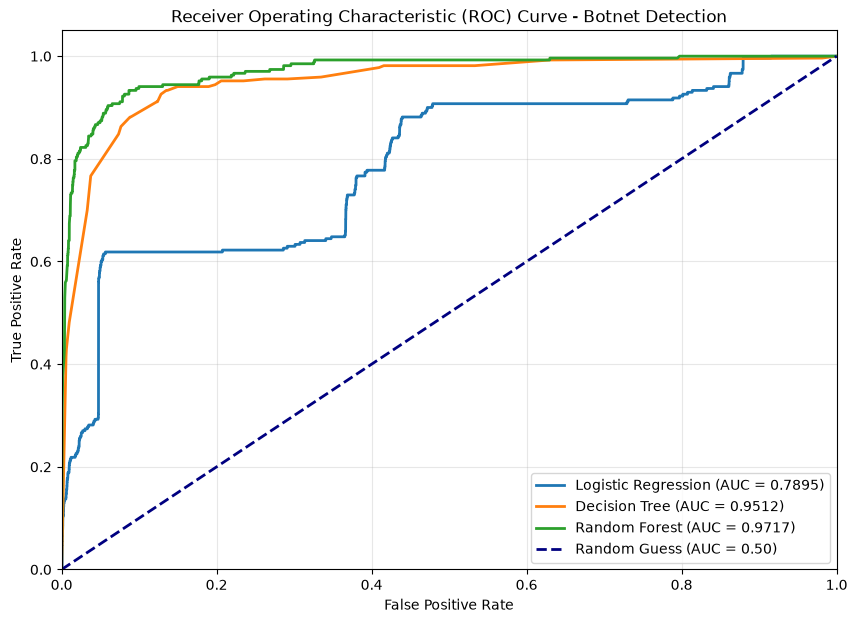

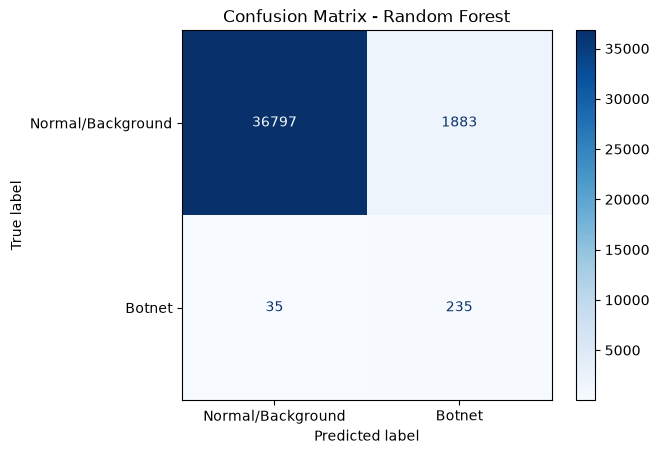

--- Completed evaluation of Random Forest ---


In [40]:
print("--- Start Model Evaluation ---")
#dictionary creation to loop over trained models
models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf
}

#the figure for the ROC curves in comparison
plt.figure(figsize=(10,7))

#dictionary to save the results
evaluation_results = {}

for name, model in models.items():
    print(f"\n--- Evaluating {name} ---")

    #label predictions (0 or 1)
    y_pred = model.predict(X_test_scaled)

    #probability predictions for class 1 (Botnet)
    y_probs = model.predict_proba(X_test_scaled)[:, 1]

    #save the main metrics (Precision, Recall, F1)
    # print the classification report
    print(classification_report(y_test, y_pred, target_names=["Normal/Background", "Botnet"]))

    #confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix di {name}:\n", cm)

    #calculation of points for the ROC curve (FPR, TPR as the threshold t varies)
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    evaluation_results[name] = {"fpr": fpr, "tpr": tpr, "auc": roc_auc, "cm": cm}

    #plot the ROC curve line for this specific model
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

#ROC curve graph
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Botnet Detection')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

#show the confusion matrix for this model
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Normal/Background", "Botnet"], cmap=plt.cm.Blues)
plt.title("Confusion Matrix - " + name)
plt.show()

print(f"--- Completed evaluation of {name} ---")